In [1]:
import pandas as pd
import numpy as np

# инструменты для папалайна и валидации
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#инструменты предобработки
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# модель классификации
from sklearn.neighbors import KNeighborsClassifier

#Бизнес-мметрики качества
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [14]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Баланс классов (целевая переменная - Churn: No-остался, Yes-ушёл)
class_counts = df["Churn"].value_counts(normalize=True) * 100
print(f"Баланс классов:")
print(f"Клиенты остались - {class_counts['No']:.1f}%")
print(f"Клиенты ушли     - {class_counts['Yes']:.1f}%")

# Делим выборку
x = df.drop("Churn", axis=1)
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Колонки датасета:", df.columns.tolist())

Баланс классов:
Клиенты остались - 73.5%
Клиенты ушли     - 26.5%
Колонки датасета: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Вывод: 
Анализ целевой переменной Churn выявил существенный дисбаланс классов: около 73.5% клиентов остались в компании и только 26.5% ушли. Это означает, что использовать accuracy в качестве основной метрики нельзя, так как модель, всегда предсказывающая класс "остался", уже будет точна на 73%. 

In [10]:
# Числовые признаки
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Категориальные признаки
categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Ветка 1: обработка чисел
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)
# Ветка 2: Обработка ктаегорий (текста)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# 1+2
preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
       ]
)
    #Итоговый ковейер: Предобработка -> Модель
clf_pipline=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", KNeighborsClassifier())
        ]
)
param_grid = {
        "classifier__n_neighbors": [3,5,9],
        "classifier__weights": ["uniform","distance"]
}
#5 Fold кросс-валидация
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#сбор всего в одно
grid_search = GridSearchCV(
        estimator=clf_pipline,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring="roc_auc",
        n_jobs=-1
    )
grid_search.fit(x_train,y_train)
best_model= grid_search.best_estimator_
print(f'\nЛучшие параметры алгоритма": {grid_search.best_params_}')


Лучшие параметры алгоритма": {'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}


Вывод: 
- В ходе построения модели был реализован полный пайплайн предобработки данных и обучения алгоритма. Все числовые признаки (tenure, MonthlyCharges, TotalCharges) обрабатываются через импутацию медианой для заполнения пропусков, после чего масштабируются с помощью StandardScaler — это критически важно для метода k-ближайших соседей, так как он чувствителен к разным диапазонам значений.
- Категориальные признаки заполняются наиболее частым значением и преобразуются в бинарные векторы через OneHotEncoder с параметром handle_unknown="ignore", что позволяет модели корректно обрабатывать новые категории в тестовой выборке, которых не было в обучающей.
- Оба пайплайна объединены в ColumnTransformer, который автоматически применяет соответствующие преобразования к нужным колонкам. Итоговый конвейер включает предобработку и классификатор KNeighborsClassifier, что гарантирует отсутствие утечки данных из теста в трейн.
- Для подбора оптимальных гиперпараметров (количество соседей n_neighbors и тип весов weights) используется GridSearchCV.

In [23]:
# Предсказания
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # вероятность класса "Ушёл"

conf_matrix = confusion_matrix(y_test, y_pred)

print("----- Матрица ошибок -----")
print(f"Истинно отрицательные (TN) - клиент остался, мы предсказали 'останется': {conf_matrix[0][0]}")
print(f"Ложноположительные (FP)    - клиент остался, мы предсказали 'уйдёт': {conf_matrix[0][1]}")
print(f"Ложноотрицательные (FN)    - клиент ушёл, мы предсказали 'останется': {conf_matrix[1][0]}")
print(f"Истинно положительные (TP) - клиент ушёл, мы предсказали 'уйдёт': {conf_matrix[1][1]}")

print("\n---- Отчёт по метрикам ----")
print(classification_report(y_test, y_pred, target_names=["Остался (0)", "Ушёл (1)"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Площадь под кривой ROC-AUC: {roc_auc:.4f}")

----- Матрица ошибок -----
Истинно отрицательные (TN) - клиент остался, мы предсказали 'останется': 883
Ложноположительные (FP)    - клиент остался, мы предсказали 'уйдёт': 152
Ложноотрицательные (FN)    - клиент ушёл, мы предсказали 'останется': 155
Истинно положительные (TP) - клиент ушёл, мы предсказали 'уйдёт': 219

---- Отчёт по метрикам ----
              precision    recall  f1-score   support

 Остался (0)       0.85      0.85      0.85      1035
    Ушёл (1)       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Площадь под кривой ROC-AUC: 0.8144


Вывод: Модель демонстрирует умеренное качество разделения классов = 0.8144, однако её способность выявлять уходящих клиентов остаётся недостаточной — точность и полнота для класса «Ушёл» составляют лишь 0.59, из-за чего 155 клиентов, фактически покинувших компанию, были ошибочно классифицированы как лояльные. 

# Предсказание суммы кредита 

In [17]:
from sklearn.model_selection import RandomizedSearchCV,KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [18]:
df_reg = df.dropna(subset=["tenure", "MonthlyCharges", "TotalCharges"]).copy()
x_reg = df_reg[["tenure", "MonthlyCharges"]]
y_reg = df_reg["TotalCharges"]

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42
)

reg_pipline =Pipeline(
    [("scaler", StandardScaler()), ("knn_reg",KNeighborsRegressor())]
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_dist={
    "knn_reg__n_neighbors": np.arange(3,30),
    "knn_reg__weights": ["uniform", "distance"]
}
random_search =RandomizedSearchCV(
    estimator=reg_pipline,
    param_distributions=param_dist,
    n_iter=10,
    cv=kf,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1
)

random_search.fit(x_train_r, y_train_r)
best_reg = random_search.best_estimator_
print(f'\nЛучшие параметры алгоритма: {random_search.best_params_}')



Лучшие параметры алгоритма: {'knn_reg__weights': 'distance', 'knn_reg__n_neighbors': np.int64(27)}


Вывод: мы узнали лучшие параметры алгоритма: {'knn_reg__weights': 'distance', 'knn_reg__n_neighbors': np.int64(27)}


In [20]:
y_pred_r = best_reg.predict(x_test_r)
def smape(y_test,y_pred):
    return 100* np.mean(
        2* np.abs(y_pred-y_test)/(np.abs(y_test)+np.abs(y_pred))
    )
mse= mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae= mean_absolute_error(y_test_r, y_pred_r)
smape_value = smape(y_test_r,y_pred_r)

print("--- Отчет по метрикамм регрессии ---")
print(f"MSE (квадратные $) {mse:,.0f}")
print(f"RMSE ($) {rmse:,.0f}")
print(f"MAE (Средняя ошибка) {mae:,.2f}")
print(f"SMAPE (ошибка в %) {smape_value:,.2f}%")

--- Отчет по метрикамм регрессии ---
MSE (квадратные $) 6,354
RMSE ($) 80
MAE (Средняя ошибка) 53.82
SMAPE (ошибка в %) 4.20%


Вывод: Основной целью анализа этих данных является прогнозирование оттока клиентов (Churn) на основе таких ключевых признаков, как срок обслуживания, тип договора и сумма ежемесячных платежей.

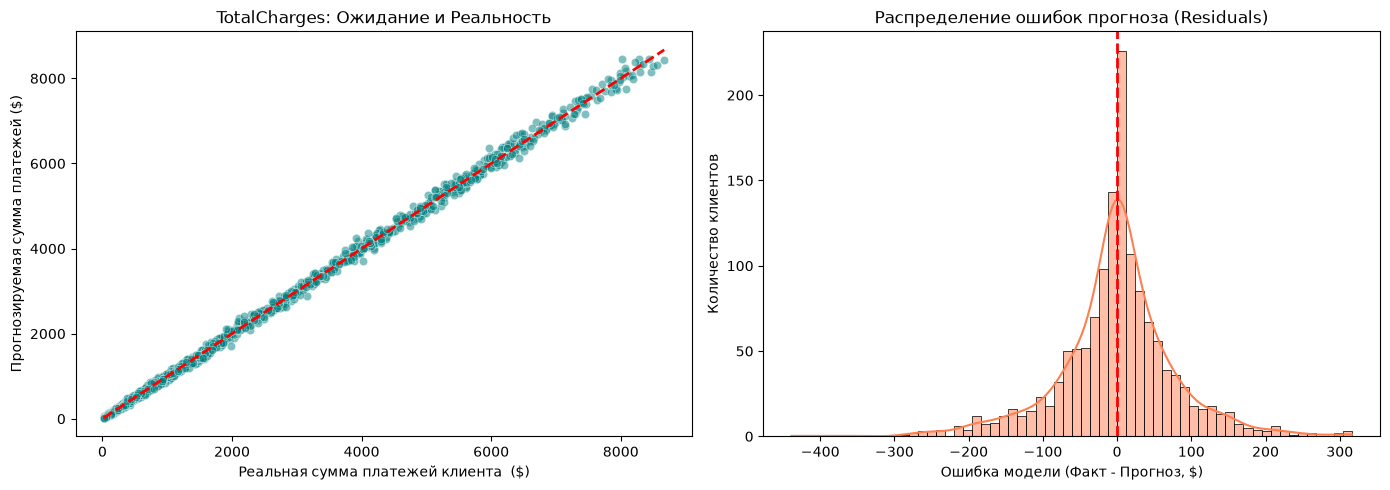

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(14,5))

# 1 График: Факт vs Прогноз
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color="teal", ax=axes[0])
y_min = min(y_test_r.min(), y_pred_r.min())
y_max = max(y_test_r.max(), y_pred_r.max())
axes[0].plot(
    [y_min, y_max], [y_min, y_max], 'r--', lw=2
)
axes[0].set_title("TotalCharges: Ожидание и Реальность")
axes[0].set_xlabel("Реальная сумма платежей клиента  ($)")
axes[0].set_ylabel("Прогнозируемая сумма платежей ($)")

# 2 График: Распределение ошибок
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, color='coral', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle="--", lw=2)  # Линия нулевой ошибки
axes[1].set_title("Распределение ошибок прогноза (Residuals)")
axes[1].set_xlabel("Ошибка модели (Факт - Прогноз, $)")
axes[1].set_ylabel("Количество клиентов")

plt.tight_layout()
plt.show()

ВЫВОД: Визуализация подтверждает высокую точность построенной регрессионной модели: точки на графике «Факт vs Прогноз» практически идеально ложатся на линию единичного наклона, что свидетельствует о сильной линейной зависимости между предсказанными и реальными значениями TotalCharges. Распределение ошибок симметрично и сфокусировано вокруг нуля с узким разбросом (преимущественно в пределах ±100 долларов), что говорит об отсутствии систематического смещения модели — она не склонна ни к завышению, ни к занижению прогнозов. Небольшие выбросы в хвостах распределения соответствуют клиентам с нестандартными условиями тарификации